### LLM Integration & Routing with Structured Output

#### Twitter - Social Media Customer Support Agent

Learning Objectives:

- Integrate LLMs into LangGraph workflows
- Use Pydantic BaseModel for structured outputs with with_structured_output()
- Implement conditional routing based on sentiment

##### Real-World Applications:

1. Customer Service: Route tickets by urgency/sentiment with appropriate responses
2. Content Moderation: Binary classification (approved/flagged) with confidence
3. Email Response: Generate tone-appropriate replies based on sentiment strength
4. Review Analysis: Classify and respond to product reviews with matching intensity
5. Social Media Management: Brand-appropriate responses scaled to sentiment


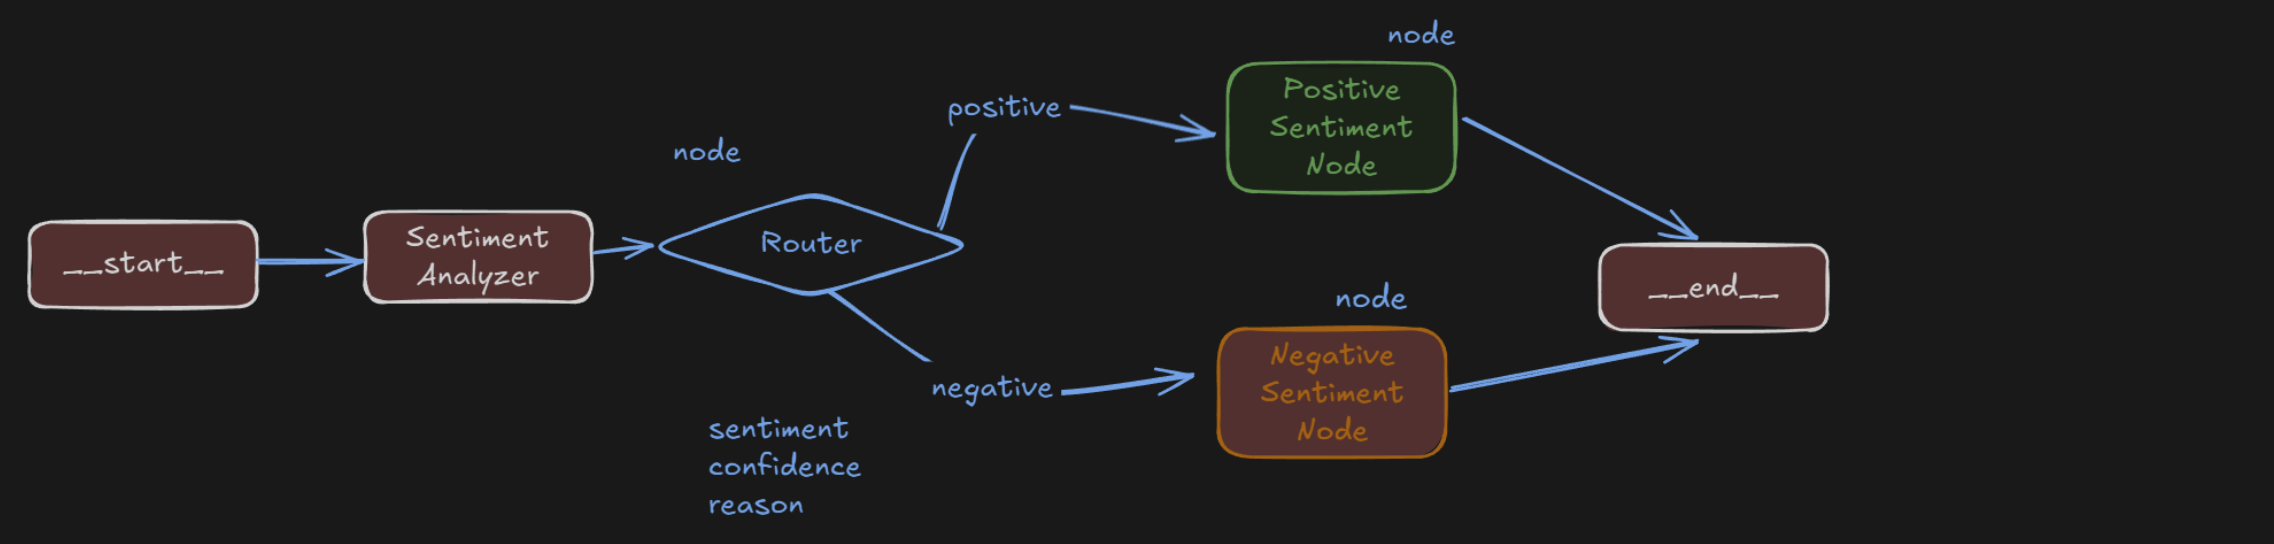


In [1]:
from typing_extensions import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

# Configuration
BASE_URL = "http://localhost:11434"
MODEL_NAME = "deepseek-r1" 

In [2]:
class SentimentAnalysis(BaseModel):
    sentiment: Literal["positive", "negative", "neutral"] = Field(..., description="The sentiment classification \
                                                                  either positive or negative or neutral")
    confidence: float = Field(..., ge=0.0, le=1.0, description="Confidence score from 0.0 to 1.0")
    reason: str = Field(..., description="Brief explanation")
    

In [3]:
# =============================================================================
# State Definition
# =============================================================================
class SentimentState(TypedDict):
    original_tweet: str
    sentiment: str
    confidence: float
    
    response_tweet: str

In [4]:
### LLM
llm = ChatOllama(model=MODEL_NAME, base_url=BASE_URL)

In [5]:
# =============================================================================
# Nodes
# =============================================================================
def analyse_sentiment(state: SentimentState) -> SentimentState:
    tweet = state["original_tweet"]
    print(f"analyzing customer tweet: {tweet}")
    
    structured_llm = llm.with_structured_output(SentimentAnalysis)
    
    messages = [
        SystemMessage("Analyze sentiment and provide the structured output. \
            Use 0 to 1.0 scale for confidence. lower is negative and higher is positive.\
            0.3 and below is negative, 0.4 to 0.7 is neutral and 0.8 and above is positive."),
        HumanMessage(tweet)
    ]
    
    analysis = structured_llm.invoke(messages)
    print(f"Sentiment Analysis is done:\n{analysis}")
    
    return {
        "sentiment": analysis.sentiment,
        "confidence": analysis.confidence
    }
    
    

In [6]:
state = {'original_tweet': "Just launched my new product!"}
analyse_sentiment(state)

analyzing customer tweet: Just launched my new product!
Sentiment Analysis is done:
sentiment='positive' confidence=0.55 reason='The phrase expresses a positive event (product launch), but lacks context or detail to increase confidence. The sentiment is clear but the score is lower due to minimal information.'


{'sentiment': 'positive', 'confidence': 0.55}